In [1]:
from pathlib import Path

import sys
import cv2
import easyocr
import matplotlib.pyplot as plt

In [2]:
# Config
DETECT_CAR = True
DETECT_LICENSE_PLATE = True
TH_PLATE_CHARS = "0123456789 กขคฆงจฉชซฌญฎฏฐฑฒณดตถทธนบปผฝพฟภมยรลวศษสหฬอฮ"

In [3]:
# Project root must be on sys.path so `import server...` works from notebook/
_root = Path.cwd().resolve()
if not (_root / "server").is_dir() and (_root.parent / "server").is_dir():
    _root = _root.parent
sys.path.insert(0, str(_root))

In [4]:
from server.lpr.ocr.preprocessing import preprocess_for_ocr

from server.lpr.yolo.car.detection import detect_cars
from server.lpr.yolo.license_plate.detection import detect_license_plates

In [5]:
reader = easyocr.Reader(['th']) 

# Recognition

## Get image


In [6]:
# Set input image path
img_path = Path("../data/images/Car3.jpg")

# Read image in BGR format
img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
if img_bgr is None:
    raise FileNotFoundError(f"Image not found at: {img_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

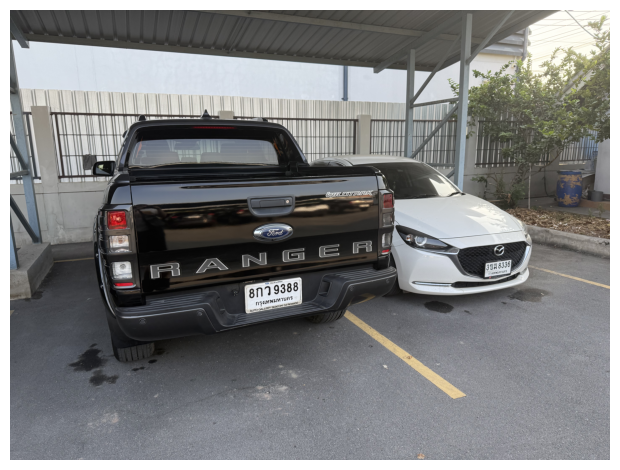

In [7]:
plt.imshow(img_rgb)
plt.axis("off")
plt.tight_layout()
plt.show()

## Car Detection


### Detect


In [8]:
if DETECT_CAR:
    result_cars = detect_cars(img_rgb, conf=0.4, iou=0.4)

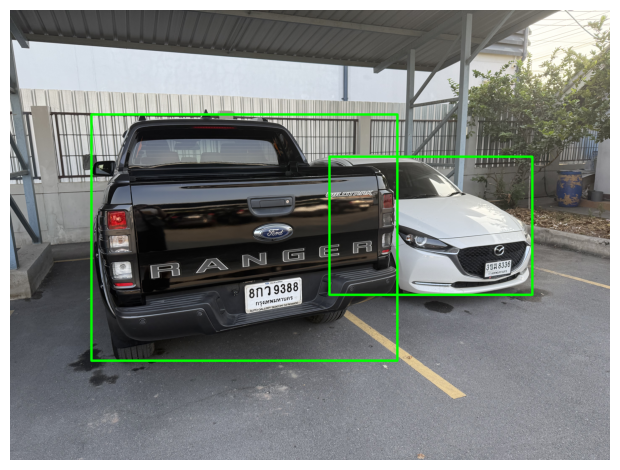

In [9]:
if DETECT_CAR:
	annotation_cars_img = img_rgb.copy()
	thickness = int(0.005 * min(annotation_cars_img.shape[:2]))

	for det in result_cars:
		b = det["bbox"]
		x1, y1, x2, y2 = int(b["x1"]), int(b["y1"]), int(b["x2"]), int(b["y2"])
		cv2.rectangle(annotation_cars_img, (x1, y1), (x2, y2), (0, 255, 0), thickness)

	plt.imshow(annotation_cars_img)
	plt.axis("off")
	plt.tight_layout()
	plt.show()
else:
	print("Not detect car")

### Crop


In [10]:
car_imgs = []

if DETECT_CAR:
	h_img, w_img = img_rgb.shape[:2]
	for det in result_cars:
		b = det["bbox"]
		x1, y1, x2, y2 = int(b["x1"]), int(b["y1"]), int(b["x2"]), int(b["y2"])
		x1, y1 = max(0, x1), max(0, y1)
		x2, y2 = min(w_img, x2), min(h_img, y2)
		if x2 <= x1 or y2 <= y1:
			continue
		car_imgs.append(img_rgb[y1:y2, x1:x2].copy())
else:
	car_imgs.append(img_rgb.copy())

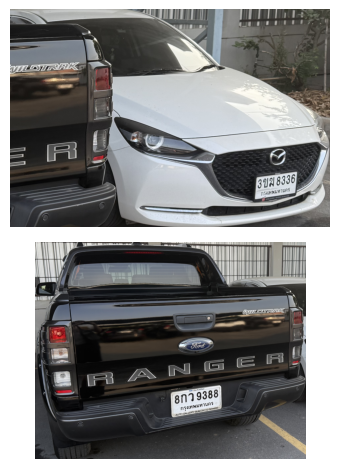

In [11]:
if len(car_imgs) > 0:
    for i in range(len(car_imgs)):
        plt.subplot(len(car_imgs), 1, i + 1)
        plt.imshow(car_imgs[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

else:
    print("No valid car crops found.")

## Get License Plate


### Detect


In [12]:
result_license_plates = []

if DETECT_LICENSE_PLATE:
    for car_img in car_imgs:
        result_license_plates.append(
            detect_license_plates(
                car_img, conf=0.3, iou=0.3, pad_x_ratio=0.1, pad_y_ratio=0.1
            )
        )

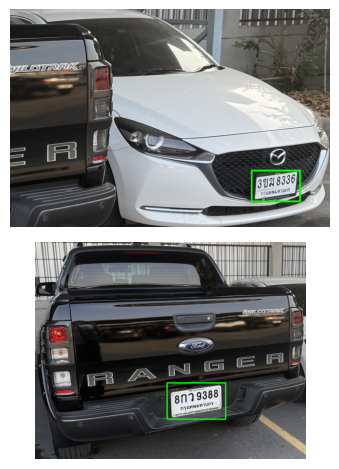

In [13]:
if DETECT_LICENSE_PLATE:
	for i in range(len(result_license_plates)):
		annotation_license_plates_img = car_imgs[i].copy()
		thickness = int(0.005 * max(annotation_license_plates_img.shape[:2]))

		for det in result_license_plates[i]:
			b = det["bbox"]
			x1, y1, x2, y2 = int(b["x1"]), int(b["y1"]), int(b["x2"]), int(b["y2"])
			cv2.rectangle(
				annotation_license_plates_img, (x1, y1), (x2, y2), (0, 255, 0), thickness
			)

		plt.subplot(len(car_imgs), 1, i + 1)
		plt.imshow(annotation_license_plates_img)
		plt.axis("off")

	plt.tight_layout()
	plt.show()
else:
	print("Not detect license plate")

### Crop


In [14]:
license_plate_imgs = []

if DETECT_LICENSE_PLATE:
	for i in range(len(result_license_plates)):
		car_img = car_imgs[i]
		h_img, w_img = car_img.shape[:2]

		for det in result_license_plates[i]:
			b = det["bbox"]
			x1, y1, x2, y2 = int(b["x1"]), int(b["y1"]), int(b["x2"]), int(b["y2"])
			x1, y1 = max(0, x1), max(0, y1)
			x2, y2 = min(w_img, x2), min(h_img, y2)

			if x2 <= x1 or y2 <= y1:
				continue

			license_plate_imgs.append(car_img[y1:y2, x1:x2].copy())
else:
	for car_img in car_imgs:
		license_plate_imgs.append(car_img.copy())

image size: (186, 292, 3)
image size: (390, 629, 3)


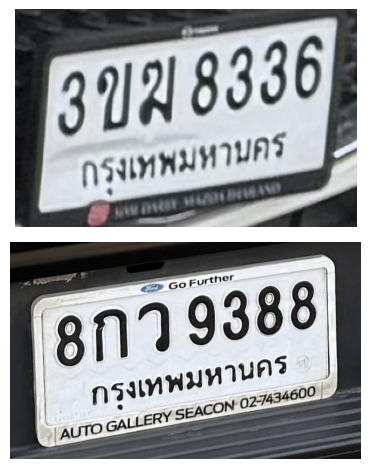

In [15]:
if len(license_plate_imgs) > 0:
    for i in range(len(license_plate_imgs)):
        print("image size:", license_plate_imgs[i].shape)
        plt.subplot(len(license_plate_imgs), 1, i + 1)
        plt.imshow(license_plate_imgs[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No valid license-plate crops found.")

## Optical Character Recognition (OCR)


### Preprocessing


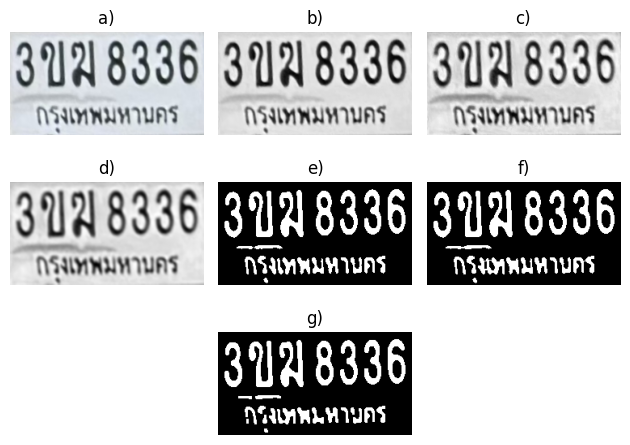

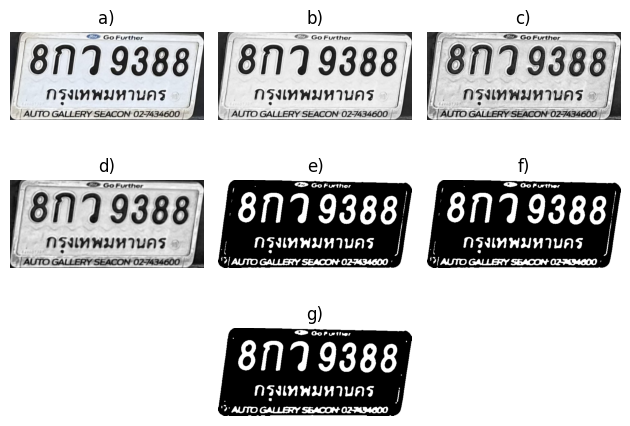

In [16]:
preprocessed_license_plate_imgs = []
steps = ["a)", "b)", "c)", "d)", "e)", "f)", "g)"]

for license_plate_img in license_plate_imgs:
	results = preprocess_for_ocr(license_plate_img)
	preprocessed_license_plate_imgs.append(results["processed"])

	for i, key in enumerate(results, start=1):
		plt.subplot(3, 3, i + (1 if key == "processed" else 0))
		plt.title(steps[i - 1])
		plt.imshow(results[key], cmap="gray")
		plt.axis("off")

	plt.tight_layout()
	plt.show()

### Extract

In [17]:
results = []

for preprocessed_license_plate_img in preprocessed_license_plate_imgs:
    results.append(
        reader.readtext(
            preprocessed_license_plate_img,
            allowlist=TH_PLATE_CHARS,
        )
    )

for result in results:
    for bbox, text, prob in result:
        print(f"Text: {text} (Confidence: {prob:.4f})")

Text: 3ขฆ836 (Confidence: 0.1499)
Text: กมมพมพวนคร (Confidence: 0.1626)
Text: 8ก29388 (Confidence: 0.9464)
Text: กรงทพมหวนคร (Confidence: 0.3979)
Text:  ศ ร 0 (Confidence: 0.0621)
